# Predicting Student Health Risk.

In [4]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print()
print("Train dtypes:")
print(train.dtypes)

Train shape: (690088, 15)
Test shape: (295753, 14)

Train dtypes:
id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object


In [5]:
print("Missing values - train:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print()
print("Missing values - test:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values - train:
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

Missing values - test:
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64


In [6]:
print("Class counts:")
print(train['health_condition'].value_counts())
print()
print("Class proportions:")
print(train['health_condition'].value_counts(normalize=True))

Class counts:
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

Class proportions:
health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64


In [7]:
numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
                 'step_count', 'exercise_duration', 'water_intake']

for col in numeric_cols:
    print(f"--- {col} ---")
    print(train.groupby('health_condition')[col].describe())
    print()

--- sleep_duration ---
                     count      mean       std   min   25%   50%   75%    max
health_condition                                                             
at-risk           527253.0  7.086467  1.143340  3.00  6.36  7.03  7.83  10.00
fit                35447.0  7.954311  0.777578  3.66  7.38  7.84  8.43  10.00
unhealthy          51389.0  5.366118  0.670365  3.00  4.97  5.53  5.79   9.99

--- heart_rate ---
                     count       mean       std   min   25%   50%   75%    max
health_condition                                                              
at-risk           585740.0  75.100534  8.192666  50.0  69.4  75.1  80.7  107.7
fit                39370.0  74.803742  8.222343  50.0  69.2  74.5  80.5  106.7
unhealthy          57145.0  75.256903  7.954250  50.0  69.8  75.1  80.6  102.5

--- bmi ---
                     count       mean       std    min    25%    50%    75%  \
health_condition                                                              
a

In [8]:
categorical_cols = ['diet_type', 'stress_level', 'sleep_quality',
                     'physical_activity_level', 'smoking_alcohol', 'gender']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(pd.crosstab(train[col], train['health_condition'], normalize='index'))
    print()

--- diet_type ---
health_condition   at-risk       fit  unhealthy
diet_type                                      
balanced          0.851394  0.061193   0.087413
non-veg           0.867802  0.051586   0.080612
veg               0.856679  0.060355   0.082966

--- stress_level ---
health_condition   at-risk       fit  unhealthy
stress_level                                   
high              0.717817  0.003511   0.278672
low               0.796670  0.200557   0.002773
medium            0.993935  0.002998   0.003067

--- sleep_quality ---
health_condition   at-risk       fit  unhealthy
sleep_quality                                  
average           0.859321  0.057280   0.083399
good              0.887772  0.081744   0.030485
poor              0.829558  0.034614   0.135828

--- physical_activity_level ---
health_condition          at-risk       fit  unhealthy
physical_activity_level                               
active                   0.743085  0.171603   0.085312
moderate           

In [9]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())
print()

# check for impossible values
for col in numeric_cols:
    neg_count = (train[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")

print()
print("Constant columns in train:")
for col in train.columns:
    if train[col].nunique() == 1:
        print(col)

print()
# overlap check between train and test on numeric features (rough near-duplicate check)
common_cols = numeric_cols
merged = train[common_cols].merge(test[common_cols], how='inner')
print("Exact numeric row matches between train and test:", len(merged))

Duplicate rows in train: 0
Duplicate rows in test: 0


Constant columns in train:

Exact numeric row matches between train and test: 0


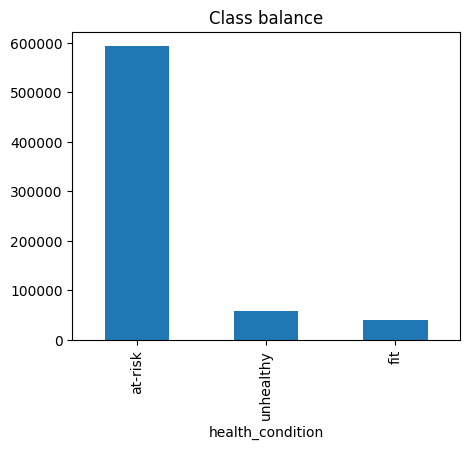

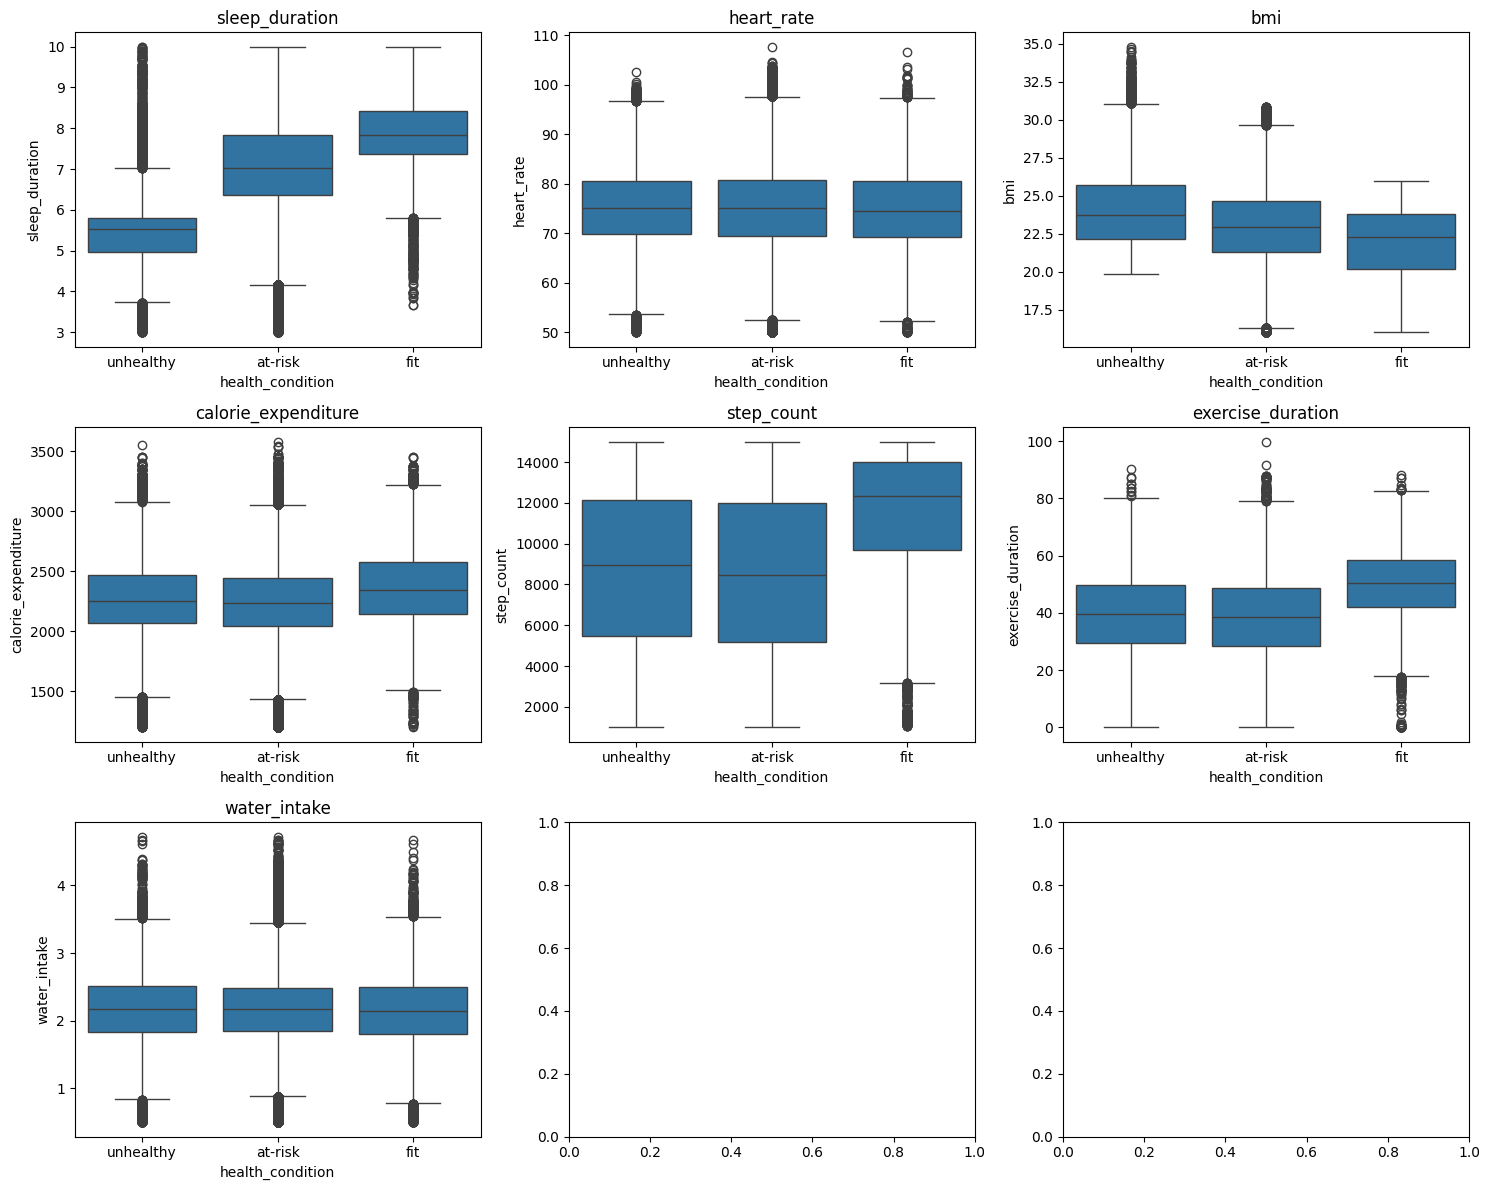

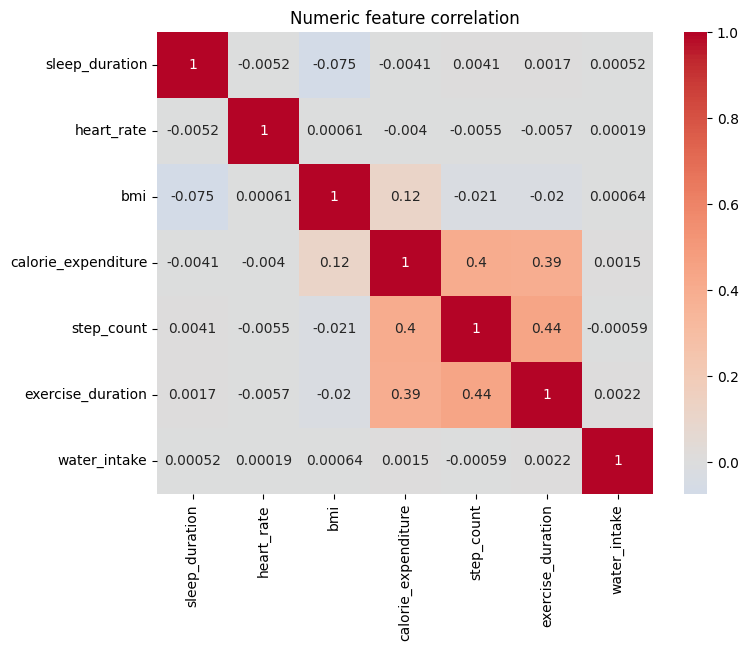

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# class balance
plt.figure(figsize=(5, 4))
train['health_condition'].value_counts().plot(kind='bar')
plt.title('Class balance')
plt.show()

# numeric distributions by class
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=train, x='health_condition', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Numeric feature correlation')
plt.show()

In [11]:
## Setup and import

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import OrdinalEncoder

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')

target_col = 'health_condition'
id_col = 'id'

In [12]:
# Define Feature group

numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
                 'step_count', 'exercise_duration', 'water_intake']

ordinal_cols = {
    'stress_level': ['low', 'medium', 'high'],
    'sleep_quality': ['poor', 'average', 'good'],
    'physical_activity_level': ['sedentary', 'moderate', 'active'],
}

onehot_cols = ['diet_type', 'smoking_alcohol', 'gender']

In [13]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = {
    'stress_level': ['low', 'medium', 'high'],
    'sleep_quality': ['poor', 'average', 'good'],
    'physical_activity_level': ['sedentary', 'moderate', 'active'],
}
onehot_cols = ['diet_type', 'smoking_alcohol', 'gender']

train_enc = train.copy()
test_enc = test.copy()

for col, order in ordinal_cols.items():
    train_enc[col] = train_enc[col].fillna('missing')
    test_enc[col] = test_enc[col].fillna('missing')
    full_order = order + ['missing']
    encoder = OrdinalEncoder(categories=[full_order], handle_unknown='use_encoded_value', unknown_value=-1)
    train_enc[col] = encoder.fit_transform(train_enc[[col]])
    test_enc[col] = encoder.transform(test_enc[[col]])

for col in onehot_cols:
    train_enc[col] = train_enc[col].fillna('missing')
    test_enc[col] = test_enc[col].fillna('missing')

train_enc = pd.get_dummies(train_enc, columns=onehot_cols)
test_enc = pd.get_dummies(test_enc, columns=onehot_cols)
train_enc, test_enc = train_enc.align(test_enc, join='left', axis=1, fill_value=0)
test_enc = test_enc.drop(columns=[target_col], errors='ignore')

train = train_enc
test = test_enc
print(train.dtypes)

id                              int64
health_condition               object
sleep_duration                float64
heart_rate                    float64
bmi                           float64
calorie_expenditure           float64
step_count                    float64
exercise_duration             float64
water_intake                  float64
stress_level                  float64
sleep_quality                 float64
physical_activity_level       float64
diet_type_balanced               bool
diet_type_missing                bool
diet_type_non-veg                bool
diet_type_veg                    bool
smoking_alcohol_missing          bool
smoking_alcohol_no               bool
smoking_alcohol_occasional       bool
smoking_alcohol_yes              bool
gender_female                    bool
gender_male                      bool
gender_missing                   bool
gender_other                     bool
dtype: object


In [25]:
train['stress_level'].unique()

array([2., 0., 3., 1.])

In [14]:
# Preprocessing function

def preprocess(train, test, numeric_cols, ordinal_cols, onehot_cols):
    train = train.copy()
    test = test.copy()

    # numeric: median imputation
    for col in numeric_cols:
        median_val = train[col].median()
        train[col] = train[col].fillna(median_val)
        test[col] = test[col].fillna(median_val)

    # ordinal: fill missing with a "missing" category, then encode
    for col, order in ordinal_cols.items():
        train[col] = train[col].fillna('missing')
        test[col] = test[col].fillna('missing')
        full_order = order + ['missing']
        encoder = OrdinalEncoder(categories=[full_order], handle_unknown='use_encoded_value', unknown_value=-1)
        train[col] = encoder.fit_transform(train[[col]])
        test[col] = encoder.transform(test[[col]])

    # onehot: fill missing with "missing" category, then one-hot encode
    for col in onehot_cols:
        train[col] = train[col].fillna('missing')
        test[col] = test[col].fillna('missing')

    train = pd.get_dummies(train, columns=onehot_cols)
    test = pd.get_dummies(test, columns=onehot_cols)

    # align columns in case of category mismatch between train/test
    train, test = train.align(test, join='left', axis=1, fill_value=0)
    test = test.drop(columns=[target_col], errors='ignore')

    return train, test

train_processed, test_processed = preprocess(train, test, numeric_cols, ordinal_cols, onehot_cols)

feature_cols = [c for c in train_processed.columns if c not in [id_col, target_col]]

X = train_processed[feature_cols]
y = train_processed[target_col]
X_test = test_processed[feature_cols]

print(X.shape, X_test.shape)
print(X.columns.tolist())

ValueError: could not convert string to float: 'low'

## Optuna Approach

In [ ]:
import numpy as np
import joblib
import optuna
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

In [16]:
label_map = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_encoded = y.map(label_map)

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("Columns match:", list(X.columns) == list(X_test.columns))

NameError: name 'y' is not defined

In [17]:
X_search_tr, X_search_val, y_search_tr, y_search_val = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

class_counts = y_search_tr.value_counts().sort_index()
weight_map = {c: len(y_search_tr) / (3 * class_counts[c]) for c in range(3)}
sample_weight_tr = y_search_tr.map(weight_map).values

NameError: name 'train_test_split' is not defined

In [29]:
def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['lightgbm', 'xgboost', 'randomforest'])

    if classifier_name == 'lightgbm':
        params = {
            'objective': 'multiclass', 'num_class': 3, 'class_weight': 'balanced',
            'random_state': 42, 'verbose': -1,
            'n_estimators': trial.suggest_int('lgb_n_estimators', 200, 600),
            'learning_rate': trial.suggest_float('lgb_learning_rate', 0.02, 0.1, log=True),
            'num_leaves': trial.suggest_int('lgb_num_leaves', 15, 90),
            'max_depth': trial.suggest_int('lgb_max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('lgb_min_child_samples', 10, 200),
            'subsample': trial.suggest_float('lgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('lgb_colsample_bytree', 0.6, 1.0),
        }
        model = lgb.LGBMClassifier(**params)
        model.fit(X_search_tr, y_search_tr)

    elif classifier_name == 'xgboost':
        params = {
            'objective': 'multi:softprob', 'num_class': 3, 'random_state': 42,
            'eval_metric': 'mlogloss',
            'n_estimators': trial.suggest_int('xgb_n_estimators', 200, 600),
            'learning_rate': trial.suggest_float('xgb_learning_rate', 0.02, 0.1, log=True),
            'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('xgb_min_child_weight', 1, 20),
            'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
        }
        model = xgb.XGBClassifier(**params)
        model.fit(X_search_tr, y_search_tr, sample_weight=sample_weight_tr)

    else:  # randomforest
        params = {
            'n_estimators': trial.suggest_int('rf_n_estimators', 200, 600),
            'max_depth': trial.suggest_int('rf_max_depth', 5, 25),
            'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 50),
            'min_samples_leaf': trial.suggest_int('rf_min_samples_leaf', 1, 30),
            'max_features': trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', 0.5]),
            'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1,
        }
        model = RandomForestClassifier(**params)
        model.fit(X_search_tr, y_search_tr)

    preds = model.predict(X_search_val)
    return balanced_accuracy_score(y_search_val, preds)

In [30]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best classifier:", study.best_params['classifier'])
print("Best score:", study.best_value)
print("Best params:", study.best_params)

joblib.dump(study.best_params, '/kaggle/working/combined_best_params.pkl')
joblib.dump(study.best_value, '/kaggle/working/combined_best_value.pkl')

[I 2026-07-29 14:30:05,912] A new study created in memory with name: no-name-6b2c84f5-4ade-4d5e-b4f2-2119c385e3a7


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-07-29 14:30:34,128] Trial 0 finished with value: 0.9495517049146458 and parameters: {'classifier': 'xgboost', 'xgb_n_estimators': 323, 'xgb_learning_rate': 0.020864069055806702, 'xgb_max_depth': 5, 'xgb_min_child_weight': 3, 'xgb_subsample': 0.8227926968917947, 'xgb_colsample_bytree': 0.7273282577096866}. Best is trial 0 with value: 0.9495517049146458.
[I 2026-07-29 14:31:12,778] Trial 1 finished with value: 0.9498228855379299 and parameters: {'classifier': 'lightgbm', 'lgb_n_estimators': 447, 'lgb_learning_rate': 0.023350865518541486, 'lgb_num_leaves': 28, 'lgb_max_depth': 8, 'lgb_min_child_samples': 189, 'lgb_subsample': 0.7716609412222968, 'lgb_colsample_bytree': 0.6651643454386952}. Best is trial 1 with value: 0.9498228855379299.
[I 2026-07-29 14:32:03,019] Trial 2 finished with value: 0.94976767395497 and parameters: {'classifier': 'lightgbm', 'lgb_n_estimators': 551, 'lgb_learning_rate': 0.02584133326545155, 'lgb_num_leaves': 74, 'lgb_max_depth': 6, 'lgb_min_child_samples

['/kaggle/working/combined_best_value.pkl']

In [31]:
best = study.best_params
winner = best['classifier']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_final = np.zeros(len(X), dtype=int)
scores_final = []

for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded.iloc[train_idx], y_encoded.iloc[val_idx]

    if winner == 'lightgbm':
        model = lgb.LGBMClassifier(
            objective='multiclass', num_class=3, class_weight='balanced', random_state=42, verbose=-1,
            n_estimators=best['lgb_n_estimators'], learning_rate=best['lgb_learning_rate'],
            num_leaves=best['lgb_num_leaves'], max_depth=best['lgb_max_depth'],
            min_child_samples=best['lgb_min_child_samples'], subsample=best['lgb_subsample'],
            colsample_bytree=best['lgb_colsample_bytree']
        )
        model.fit(X_tr, y_tr)

    elif winner == 'xgboost':
        wmap = {c: len(y_tr) / (3 * y_tr.value_counts().sort_index()[c]) for c in range(3)}
        sw = y_tr.map(wmap).values
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3, random_state=42, eval_metric='mlogloss',
            n_estimators=best['xgb_n_estimators'], learning_rate=best['xgb_learning_rate'],
            max_depth=best['xgb_max_depth'], min_child_weight=best['xgb_min_child_weight'],
            subsample=best['xgb_subsample'], colsample_bytree=best['xgb_colsample_bytree']
        )
        model.fit(X_tr, y_tr, sample_weight=sw)

    else:
        model = RandomForestClassifier(
            n_estimators=best['rf_n_estimators'], max_depth=best['rf_max_depth'],
            min_samples_split=best['rf_min_samples_split'], min_samples_leaf=best['rf_min_samples_leaf'],
            max_features=best['rf_max_features'], class_weight='balanced', random_state=42, n_jobs=-1
        )
        model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    oof_final[val_idx] = preds
    scores_final.append(balanced_accuracy_score(y_val, preds))

print(f"Winner: {winner}")
print(f"5-fold CV: mean={np.mean(scores_final):.5f}, OOF={balanced_accuracy_score(y_encoded, oof_final):.5f}")

joblib.dump(oof_final, '/kaggle/working/oof_final_combined.pkl')
joblib.dump(best, '/kaggle/working/final_winner_params.pkl')

Winner: lightgbm
5-fold CV: mean=0.94962, OOF=0.94962


['/kaggle/working/final_winner_params.pkl']

In [2]:
from optuna.visualization import plot_optimization_history

plot_optimization_history(study).show()

NameError: name 'study' is not defined

In [40]:
import joblib
import pandas as pd
import lightgbm as lgb

best = joblib.load('/kaggle/working/final_winner_params.pkl')

final_model = lgb.LGBMClassifier(
    objective='multiclass', num_class=3, class_weight='balanced', random_state=42, verbose=-1,
    n_estimators=best['lgb_n_estimators'],
    learning_rate=best['lgb_learning_rate'],
    num_leaves=best['lgb_num_leaves'],
    max_depth=best['lgb_max_depth'],
    min_child_samples=best['lgb_min_child_samples'],
    subsample=best['lgb_subsample'],
    colsample_bytree=best['lgb_colsample_bytree']
)

final_model.fit(X, y_encoded)
joblib.dump(final_model, '/kaggle/working/final_model_combined_search.pkl')

test_proba = final_model.predict_proba(X_test)
final_preds = test_proba.argmax(axis=1)
final_labels = [inv_label_map[p] for p in final_preds]

submission = pd.DataFrame({
    id_col: test[id_col],
    target_col: final_labels
})
submission.to_csv('/kaggle/working/submission.csv', index=False)

print(submission.head())
print(submission[target_col].value_counts())
print(submission[target_col].value_counts(normalize=True))

       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
health_condition
at-risk      239863
unhealthy     34126
fit           21764
Name: count, dtype: int64
health_condition
at-risk      0.811025
unhealthy    0.115387
fit          0.073588
Name: proportion, dtype: float64
